# Benchmark: C3794 Two-Cavity Module vs CST Studio Suite

This benchmark computes the S- and Z-parameters of a two-cavity module and compares them with
CST Studio Suite over 0.1–1.0 GHz. Each cavity is a C3794 cavity with a fundamental power
coupler (FPC) and a higher-order-mode (HOM) coupler, both coaxial.

The module is built the reduced-order way. One cavity is solved at full order and reduced to a
small model, and two copies of that model are coupled through the beam pipe. The CST reference
meshes and solves the whole module as one problem.

**Downloads**

| File | Contents |
|---|---|
| [c3794_4hc_1fpc_w_TEM.stp](https://dark-elektron.github.io/cavsim3d/example_models/c3794/c3794_4hc_1fpc_w_TEM.stp) | Geometry of one cavity (STEP, exported from CST, millimetres) |
| [E_C3794_1HC_1FPC_ports_w_TEM_2cav_module.cst](https://dark-elektron.github.io/cavsim3d/example_models/c3794/E_C3794_1HC_1FPC_ports_w_TEM_2cav_module.cst) | CST Studio Suite project of the two-cavity reference |
| [c3794_2cav_module.npz](https://dark-elektron.github.io/cavsim3d/example_models/c3794/c3794_2cav_module.npz) | The results shown on this page, from both codes on the same 1001-point grid |

The page shows a complete run (`RUN_SIMULATION = True` below); the downloadable results come
from the same settings. To plot them without solving, set `RUN_SIMULATION = False`. To run
elsewhere, put the downloads in one folder and set `DATA_DIR` to it. To check the reference,
solve the CST project and set `CST_PROJECT` to its folder.

## The model

The STEP file contains five solids: the vacuum region, the ceramic window of the FPC
($\varepsilon_r = 10$) and three metal parts. The metal parts are treated as perfect conductors
and removed from the computational domain. Each cavity has four ports: the two ends of the
150 mm-radius beam pipe, and the FPC and HOM coaxial lines.

Several modes propagate in the beam pipe within the band:

| Beam-pipe mode | Cutoff |
|---|---|
| TE$_{11}$ (two polarisations) | 585.7 MHz |
| TM$_{01}$ | 765.0 MHz |
| TE$_{21}$ (two polarisations) | 971.5 MHz |

Each beam-pipe port therefore carries all five modes, and each coaxial port carries its TEM mode.
A port mode that is left out sees a magnetic wall at the port. At the junction between two
cavities that mode would be reflected instead of passing through, so the junction needs every
mode that can propagate.

| Setting | Value |
|---|---|
| Elements | second order, first-kind Nédélec |
| Mesh size bound (`maxh`) | 0.03 m ($\lambda/10$ at 1 GHz); 0.05 m on the port faces |
| Full-order unknowns per cavity | 756,724 |
| Snapshots (full-order solves) | 50, spread over 0.1–1.0 GHz |
| POD tolerance | $10^{-8}$ |
| Frequency sweep | 1001 points |

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from cavsim3d.analysis import (band_difference, keep_port_modes, network_matrix,
                               plot_entries, plot_matrix)

# Folder with the downloads above (their place in the repository)
DATA_DIR = Path("../../example_models/c3794")
STEP_FILE = DATA_DIR / "c3794_4hc_1fpc_w_TEM.stp"
SAVED = np.load(DATA_DIR / "c3794_2cav_module.npz")

# True reruns the workflow below. On a 16-core laptop (Intel Core Ultra
# 7 255H, 64 GB) the full-order solve of one cavity takes about 20
# minutes and 15 GB of memory. False uses the saved results.
RUN_SIMULATION = True

# Optional: a solved CST project folder whose Export folder holds the
# ASCII S- and Z-parameter exports.
CST_PROJECT = None

## 1. Solve one cavity and reduce it

The cavity is meshed, solved at full order at 50 frequencies (the snapshots) and reduced by
proper orthogonal decomposition. `maxh` is in metres, NGSolve's unit. This step dominates the
cost, and it is done once: every module built afterwards reuses the saved reduced model.

In [2]:
from cavsim3d.core.em_project import EMProject

WORK = Path("./simulations")
BAND = dict(fmin=0.1, fmax=1.0)          # GHz
# five modes on each beam pipe, the TEM mode on each coaxial port
PORT_MODES = {"port1": 5, "port2": 5, "default": 1}
MATERIALS = {"lh4*": "PEC", "dh2*": "PEC", "solid": "PEC",  # metal
             "ceramic*": {"eps_r": 10},                     # FPC window
             "solid1*": {"eps_r": 1}}                       # vacuum

if RUN_SIMULATION:
    cavity = EMProject(name="c3794_cavity", base_dir=str(WORK),
                       overwrite=True)
    geo = cavity.import_geometry(STEP_FILE, name="cavity", unit="mm",
                                 auto_build=False)
    geo.set_materials(MATERIALS)
    geo.build()
    geo.set_local_mesh_refinement("port*", 0.05)       # port faces
    geo.generate_mesh(maxh=0.03, curvaturesafety=1.5)  # lambda/10

✅ Creating new project 'c3794_cavity' at simulations\c3794_cavity



STEP solids found:
  - lh4
  - dh2
  - ceramic
  - solid1
  - solid



Ports found: 4

Material properties assigned: 2 dielectric, 3 PEC


Named 6 solids (5 unique materials):
  solid 0: 'lh4'
  solid 1: 'ceramic'
  solid 2: 'solid'
  solid 3: 'solid1'
  solid 4: 'dh2'
  solid 5: 'solid1'
Ports matched: 4/4
  port1                center=(-0.00000, 0.00000, 1.12200)  normal=(-0.0000, 0.0000, 1.0000)
  port2                center=(0.00000, 0.00000, -1.12860)  normal=(0.0000, 0.0000, -1.0000)
  port3                center=(0.00000, 0.20000, -0.46650)  normal=(-0.0000, 1.0000, 0.0000)
  port4                center=(-0.49479, -0.13525, -0.46650)  normal=(-0.9646, -0.2637, 0.0000)
Subtracting 3 PEC solid(s): ['lh4', 'dh2', 'solid']
Local mesh refinement maxh=0.05 applied to 4 face(s) and 0 solid(s) matching 'port*'


In [3]:
print(geo.mesh.ne)

110428


The full-order sweep writes each finished sample to the project as it goes. If it is
interrupted, run the next cell again: it continues from the samples already computed.
After a kernel restart, reopen the project instead of running the cell above (its
`overwrite=True` starts from scratch):
`cavity = EMProject(name="c3794_cavity", base_dir=str(WORK))`.

In [4]:
if RUN_SIMULATION:
    cavity.fds.solve(config=dict(**BAND, nsamples=50, order=2,
                                 nedelec="first",  # first-kind elements (default)
                                 solver_type="direct", verbose=True,
                                 nportmodes=PORT_MODES))
    cavity.fds.fom.reduce(tol=1e-8)   # every stage saves itself


Structure Topology
  Type: Single structure
  Domains (2): ['ceramic', 'solid1']
  Ports (4): ['port1', 'port2', 'port3', 'port4']
  Mesh elements: 110428


  No valid results found. Forcing compute. (Z_coupled=False, foms=False, fmin=None)


Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


INFO:: ============================================================


INFO::   Mode source: analytic


INFO::   Polarization angle: 0.0°


INFO::   Requested modes per port: {'port1': 5, 'port2': 5, 'default': 1}


INFO:: ------------------------------------------------------------


INFO::   port1: circular (fit error: 0.0000)


    R=0.150000


INFO::   port2: circular (fit error: 0.0000)


    R=0.150000


INFO::   port3: coaxial (fit error: 0.0000)


    R_outer=0.072501, R_inner=0.020756


INFO::   port4: coaxial (fit error: 0.0000)


    R_outer=0.023500, R_inner=0.009200


  Precomputing boundary mass matrices (once per port)...


    Done for 4 port(s)


  Port order: ['port1', 'port2', 'port3', 'port4']


  Analytic calculation for port port1 (5 mode(s))


	port1 mode 0: TE_11 (cos), kc=12.2745, sigma=+1


	port1 mode 1: TE_11 (sin), kc=12.2745, sigma=+1
	port1 mode 2: TM_01, kc=16.0321, sigma=+1


	port1 mode 3: TE_21 (cos), kc=20.3616, sigma=+1


	port1 mode 4: TE_21 (sin), kc=20.3616, sigma=+1
  Analytic calculation for port port2 (5 mode(s))


	port2 mode 0: TE_11 (cos), kc=12.2745, sigma=+1


	port2 mode 1: TE_11 (sin), kc=12.2745, sigma=+1


	port2 mode 2: TM_01, kc=16.0321, sigma=+1


	port2 mode 3: TE_21 (cos), kc=20.3616, sigma=+1


	port2 mode 4: TE_21 (sin), kc=20.3616, sigma=+1
  Analytic calculation for port port3 (1 mode(s))


	port3 mode 0: TEM_00, kc=0.0000, sigma=+1
  Analytic calculation for port port4 (1 mode(s))


	port4 mode 0: TEM_00, kc=0.0000, sigma=+1
Port eigenmodes complete: 12 total modes



--- Assembling Global Matrices (Coupled System) ---


  Material eps_r per mesh material: [10.0, 1.0, 1.0]


  Material CFs: eps_r=[10.0, 1.0, 1.0], mu_r=[1.0, 1.0, 1.0]


  Global FES ndof: 756724


  K_global shape: (756724, 756724), nnz: 31208072


  M_global shape: (756724, 756724), nnz: 31208072


  B_global shape: (756724, 12)


INFO:: Saving project to simulations\c3794_cavity


Saved port modes to simulations\c3794_cavity\fds\port_modes\port_modes.pkl


INFO:: FrequencyDomainSolver saved to simulations\c3794_cavity\fds



FDS Solve: 0.1000 - 1.0000 GHz, 50 samples


INFO:: ============================================================


INFO:: Frequency Domain Solve Configuration


INFO:: ============================================================


INFO:: Frequency range: 0.1000 - 1.0000 GHz


INFO:: Number of samples: 50


INFO:: Structure type: Single


INFO:: Per-domain solve: False


INFO:: Global method: coupled


INFO:: ============================================================


Global Coupled Solve


  Material eps_r per mesh material: [10.0, 1.0, 1.0]


  Material CFs: eps_r=[10.0, 1.0, 1.0], mu_r=[1.0, 1.0, 1.0]


  Pre-assembling 12 RHS vectors...


  DOFs: 756724 total, 646272 free


  Frequency 1/50: 0.1000 GHz


  	samples 1-5: 124.0 s (24.8 s/sample)


  Frequency 6/50: 0.1918 GHz


  	samples 6-10: 129.8 s (26.0 s/sample)


  Frequency 11/50: 0.2837 GHz


  	samples 11-15: 131.0 s (26.2 s/sample)


  Frequency 16/50: 0.3755 GHz


  	samples 16-20: 128.4 s (25.7 s/sample)


  Frequency 21/50: 0.4673 GHz


  	samples 21-25: 129.8 s (26.0 s/sample)


  Frequency 26/50: 0.5592 GHz


  	samples 26-30: 128.0 s (25.6 s/sample)


  Frequency 31/50: 0.6510 GHz


  	samples 31-35: 129.1 s (25.8 s/sample)


  Frequency 36/50: 0.7429 GHz


  	samples 36-40: 122.6 s (24.5 s/sample)


  Frequency 41/50: 0.8347 GHz


  	samples 41-45: 122.5 s (24.5 s/sample)


  Frequency 46/50: 0.9265 GHz


  	samples 46-50: 123.8 s (24.8 s/sample)


  
Coupled solve complete: 4 external ports in 1269.34s


INFO:: Saving project to simulations\c3794_cavity


Saved port modes to simulations\c3794_cavity\fds\port_modes\port_modes.pkl


INFO:: FrequencyDomainSolver saved to simulations\c3794_cavity\fds


Model Order Reduction


Reduction complete: 756724 -> 160 DOFs (100.0% compression)


## 2. Couple two cavities

The solved cavity is imported into a new project as one part used twice (`n=2`). By default the
module reads the cavity's saved results where they are (`mode='reference'`); nothing is copied.
The copies are chained in list order along $+z$: the upper beam-pipe end of the first copy joins
the lower end of the second, and the two reduced models are coupled through the five beam-pipe
modes at that junction. Only the coupled system, a few hundred unknowns, is solved at the 1001
sweep points.

In [5]:
if RUN_SIMULATION:
    module = EMProject(name="c3794_module2", base_dir=str(WORK),
                       overwrite=True)
    module.import_project(cavity.project_path, name="cavity", n=2)
    module.fds.solve(config=dict(**BAND, nsamples=10, order=2,
                                 nportmodes=PORT_MODES))  # prints the plan
    concat = module.fds.foms.reduce(tol=1e-8).concatenate()
    concat.solve(config=dict(**BAND, nsamples=1001,
                             solver_type="direct"))
    print(f"coupled system: {concat.A_coupled.shape[0]} unknowns")

✅ Creating new project 'c3794_module2' at simulations\c3794_module2


✅ Mesh strategy: coupled (imported: cavity; repeated: cavity (n=2)): each unique part is solved on its own and the parts are joined through their port modes.


✅ Solve plan:
  cavity  imported (reference) reuse     its reduced model fits the request


✅ Netlist FOM stage complete: 1 unique section(s) for 2 instance(s)


Reduced models reused: cavity



Concat Solve: 0.1 - 1.0 GHz, 1001 samples, system size 315


  Concat solve complete: 1.105s (1001 frequencies)


coupled system: 315 unknowns


## 3. Ports and modes in the two models

The two models number their ports differently:

| Port here | Location | CST port |
|---|---|---|
| 1 | beam pipe, bottom ($z^-$) | 2 |
| 2 | FPC, lower cavity | 6 |
| 3 | HOM coupler, lower cavity | 7 |
| 4 | beam pipe, top ($z^+$) | 1 |
| 5 | FPC, upper cavity | 3 |
| 6 | HOM coupler, upper cavity | 4 |

They also define different modes at the beam pipes. The CST model defines three modes at its
bottom port (TE$_{11}$ in both polarisations, and TM$_{01}$) and one at its top port
(TE$_{11}$). CST's first TE$_{11}$ mode is the polarisation numbered second here.

To compare like with like, the coupled model is expressed in CST's port definition. The modes
are relabelled, and every mode that CST does not define is closed with an open circuit
($I = 0$), which is how a port treats a mode it does not define. With pseudo-wave
S-parameters an open circuit reflects with $\Gamma = +1$, so keeping the modes $k$ and closing
the modes $d$ gives

$$
\mathbf{S}' = \mathbf{S}_{kk} + \mathbf{S}_{kd}\,(\mathbf{I} - \mathbf{S}_{dd})^{-1}\,\mathbf{S}_{dk},
\qquad \mathbf{Z}' = \mathbf{Z}_{kk} .
$$

In the code this is `keep_port_modes` from `cavsim3d.analysis`.

In [6]:
# Compared port modes as port(mode), in CST's mode numbering
LABELS = ["1(1)", "1(2)", "1(3)", "2(1)", "3(1)", "4(1)", "5(1)", "6(1)"]
CST_LABELS = ["2(1)", "2(2)", "2(3)", "6(1)", "7(1)", "1(1)", "3(1)",
              "4(1)"]
# The two TE11 polarisations are numbered the other way round here
OUR_LABEL = {"1(1)": "1(2)", "1(2)": "1(1)", "4(1)": "4(2)"}

freq = SAVED["frequency_GHz"]
S_cst, Z_cst = SAVED["S_cst"], SAVED["Z_cst"]
if RUN_SIMULATION:
    freq = np.asarray(concat.frequencies) / 1e9
    # S and Z on CST's port modes; every other mode open-circuited
    S, Z = keep_port_modes(concat, [OUR_LABEL.get(x, x) for x in LABELS])
else:
    S, Z = SAVED["S_ns50"], SAVED["Z_ns50"]
if CST_PROJECT is not None:
    from cavsim3d.analytical.cst_result import CSTResult
    cst = CSTResult(CST_PROJECT).interpolate_to(freq * 1e9)
    S_cst = network_matrix(cst, CST_LABELS, kind="S")
    Z_cst = network_matrix(cst, CST_LABELS, kind="Z")

print(f"{len(freq)} frequencies, {len(LABELS)} port modes compared")

1001 frequencies, 8 port modes compared


## 4. S-parameters

The fundamental mode of every port: TE$_{11}$ at the beam pipes and TEM at the couplers.
Entry $(i, j)$ is the response at port $i$ to an excitation at port $j$.

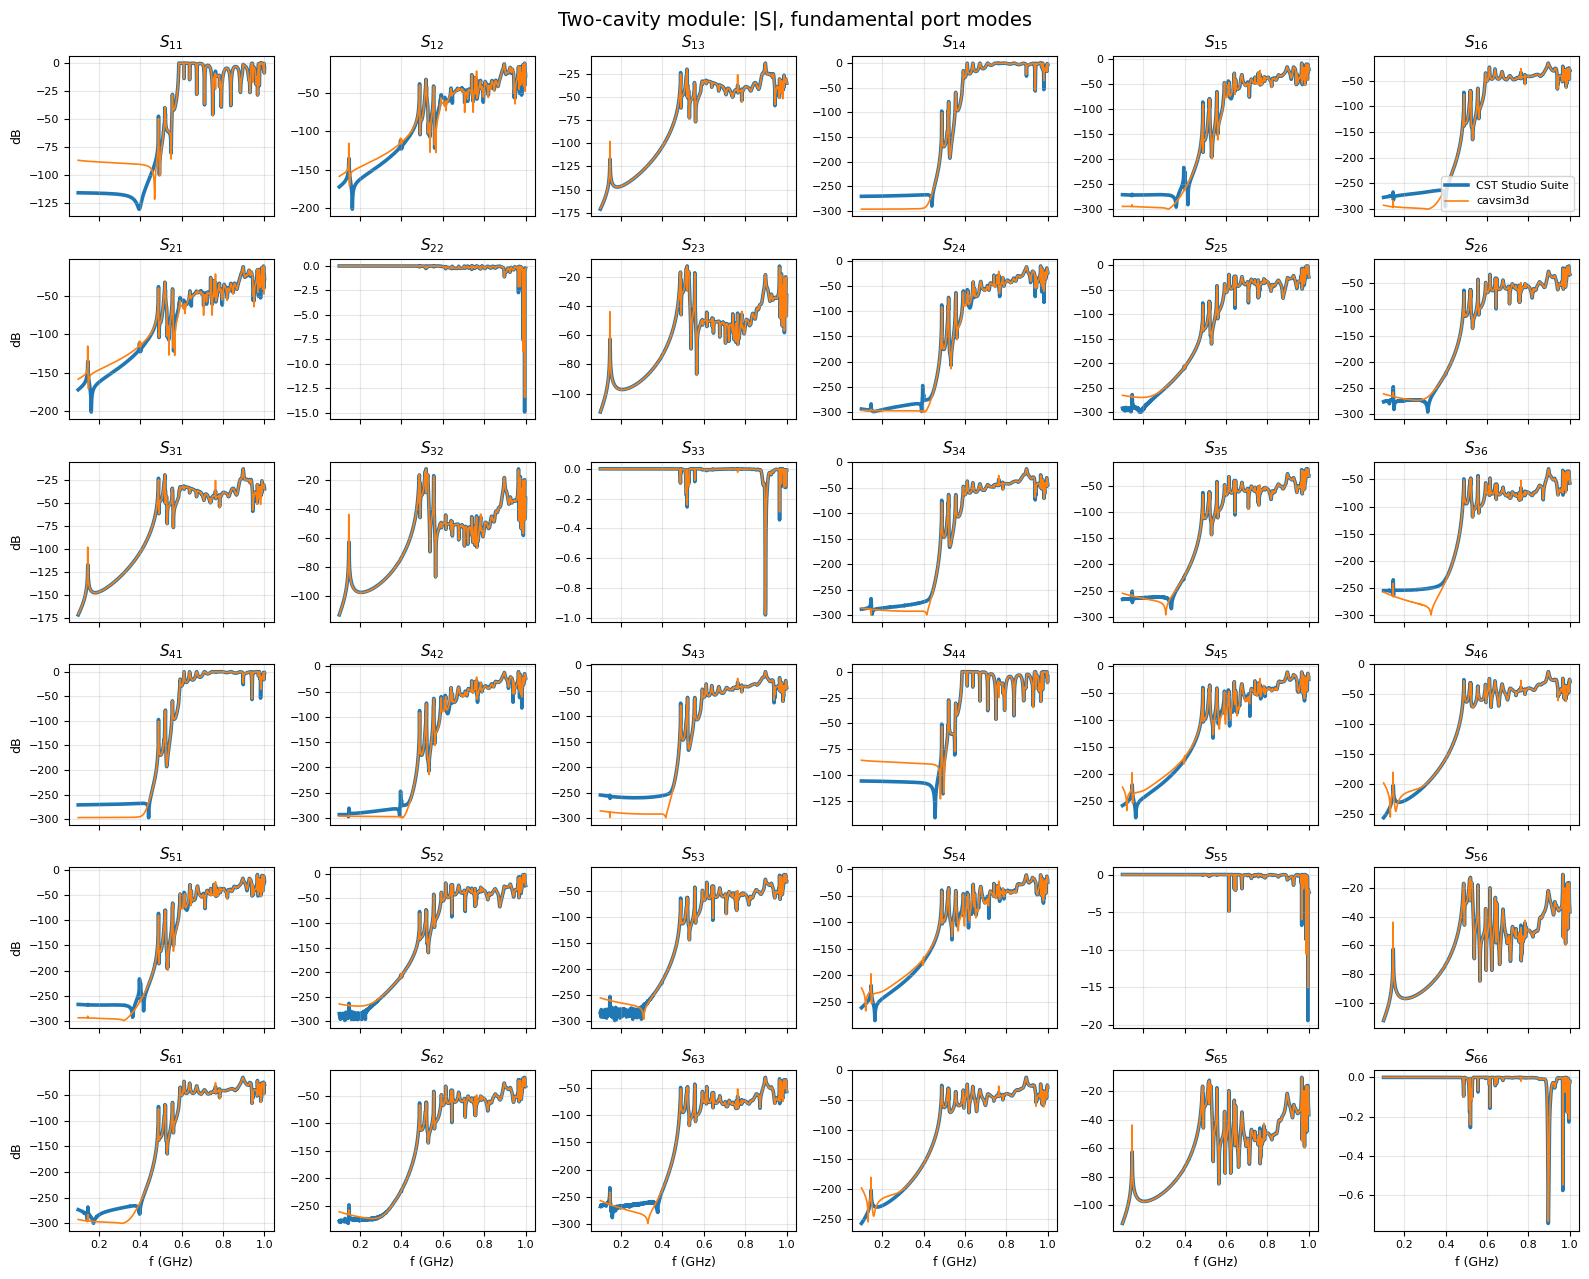

In [7]:
MAIN = [0, 3, 4, 5, 6, 7]            # fundamental mode of each port
PORT_NO = [x[0] for x in LABELS]      # port of every compared mode
S_models = {"CST Studio Suite": S_cst, "cavsim3d": S}
Z_models = {"CST Studio Suite": Z_cst, "cavsim3d": Z}

fig, axs = plot_matrix(S_models, freq, ports=MAIN, labels=PORT_NO,
                       figsize=(16, 13),
                       title="Two-cavity module: |S|, fundamental port modes")

A closer look at three entries: the FPC reflection of the upper cavity, the transmission from
the upper to the lower FPC, and the transmission through the whole module along the beam
pipe.

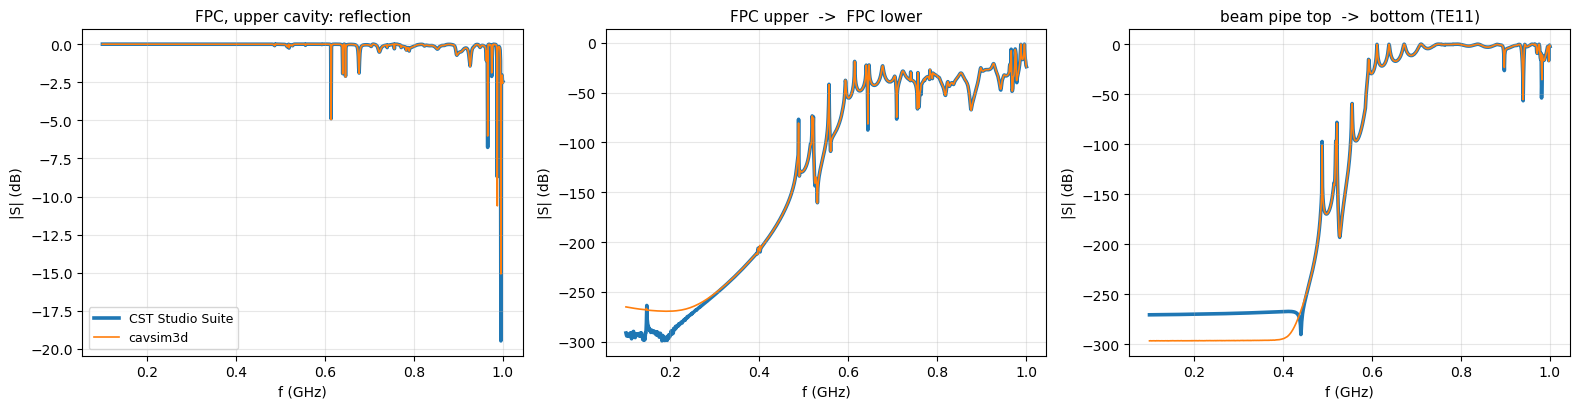

In [8]:
fig, axs = plot_entries(S_models, [(6, 6, "FPC, upper cavity: reflection"),
                                  (3, 6, "FPC upper  ->  FPC lower"),
                                  (0, 5, "beam pipe top  ->  bottom (TE11)")],
                        freq)

## 5. Z-parameters

The same entries of the impedance matrix, with the coaxial ports referenced to their line
impedance and the beam-pipe modes to their wave impedance.

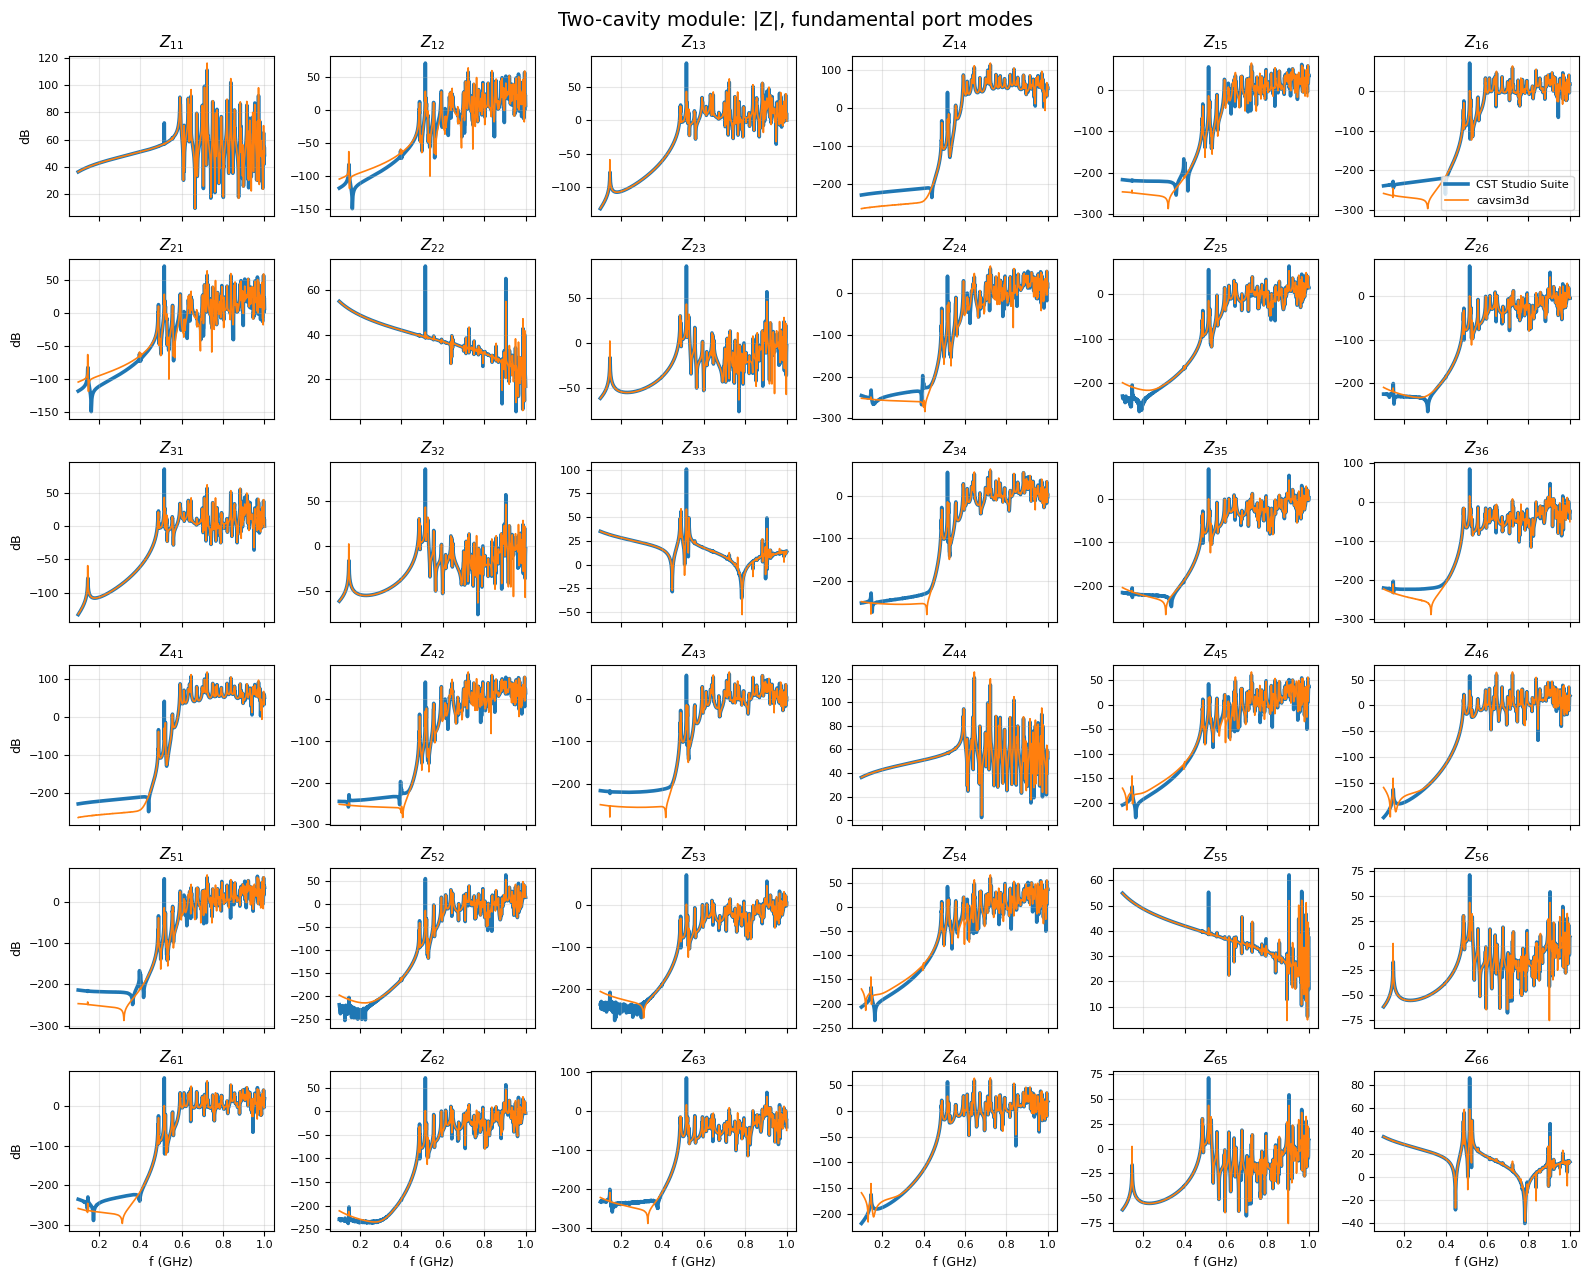

In [9]:
fig, axs = plot_matrix(Z_models, freq, ports=MAIN, labels=PORT_NO, kind="Z",
                       figsize=(16, 13),
                       title="Two-cavity module: |Z|, fundamental port modes")

## 6. The other modes at the bottom beam pipe

CST defines the second TE$_{11}$ polarisation and TM$_{01}$ at its bottom port as well, so
these can be compared too.

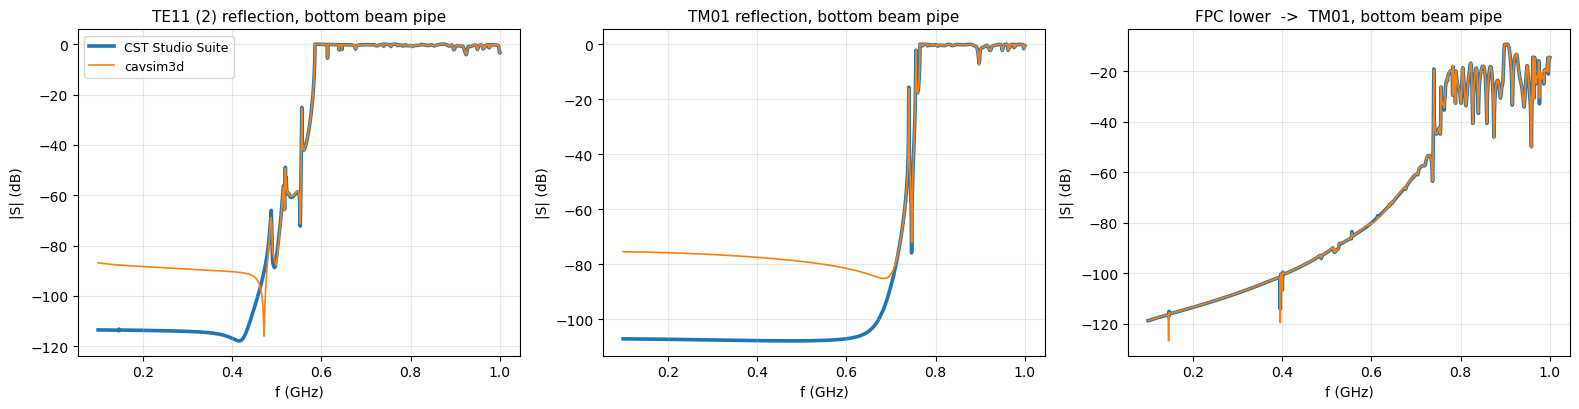

In [10]:
fig, axs = plot_entries(S_models, [(1, 1, "TE11 (2) reflection, bottom beam pipe"),
                                  (2, 2, "TM01 reflection, bottom beam pipe"),
                                  (2, 3, "FPC lower  ->  TM01, bottom beam pipe")],
                        freq)

## 7. Agreement by frequency band

Mean difference in $|S|$ over the compared entries. The band edges are the beam-pipe cutoffs.

In [11]:
EDGES = [0.1, 0.45, 0.5857, 0.765, 0.9, 0.9715, 1.0]   # GHz

table = pd.DataFrame({
    "fundamental modes": band_difference(S, S_cst, freq, EDGES, ports=MAIN),
    "all compared modes": band_difference(S, S_cst, freq, EDGES),
}).rename_axis("band (GHz)").reset_index()
table.style.format({"fundamental modes": "{:.1e}",
                    "all compared modes": "{:.1e}"}).hide(axis="index")

band (GHz),fundamental modes,all compared modes
0.100-0.450,3.9e-06,6.1e-06
0.450-0.586,1.7e-04,1.1e-04
0.586-0.765,4.0e-04,3.7e-04
0.765-0.900,3.7e-04,4.7e-04
0.900-0.972,2.0e-03,1.6e-03
0.972-1.000,2.0e-03,1.8e-03


## 8. Snapshots, model size and cost

The same comparison with 10, 30 and 50 snapshots, and what each stage costs. Times are wall-clock
on the laptop named above.

In [12]:
FMT = {"reduced model (DOFs)": "{:.0f}",
       "coupled system (DOFs)": "{:.0f}",
       "full-order solve (s)": "{:.0f}",
       "reduction (s)": "{:.1f}",
       "coupling (s)": "{:.1f}",
       "1001-point sweep (s)": "{:.2f}",
       "mean |S| difference above 585.7 MHz": "{:.1e}"}
above = freq > 0.5857
columns = {}
for k, ns in enumerate(SAVED["conv_n_samples"].astype(int)):
    diff = np.abs(np.abs(SAVED[f"S_ns{ns}"]) - np.abs(S_cst))[above]
    values = [SAVED["conv_rom_dofs"][k], SAVED["conv_concat_dofs"][k],
              SAVED["conv_t_fom"][k], SAVED["conv_t_rom"][k],
              SAVED["conv_t_build"][k], SAVED["conv_t_sweep"][k],
              diff.mean()]
    columns[f"{ns} snapshots"] = {row: FMT[row].format(v)
                                  for row, v in zip(FMT, values)}
pd.DataFrame(columns)

,10 snapshots,30 snapshots,50 snapshots
reduced model (DOFs),110,160,160
coupled system (DOFs),215,315,315
full-order solve (s),221,669,1046
reduction (s),13.2,42.9,51.7
coupling (s),0.3,0.5,0.5
1001-point sweep (s),0.82,2.51,1.57
mean |S| difference above 585.7 MHz,2.6e-02,7.5e-04,7.2e-04


With 30 snapshots the reduced model has converged: 50 snapshots add no basis vector and
change the difference from CST by less than $10^{-4}$. Ten snapshots are too few above about
0.7 GHz, where the cavity's resonances crowd together.

For scale, the CST reference solves the whole module with second-order elements on 1,914,415
tetrahedra (11,896,426 unknowns). Here each cavity has 110,428 tetrahedra (756,724
unknowns), solved once; the coupled module has 315 unknowns. A longer chain is built from the
same saved cavity with no further full-order solve.

## 9. Reading the curves below 585.7 MHz

Below the TE$_{11}$ cutoff every beam-pipe mode is evanescent, and the beam-pipe entries
become very small. Three kinds of curve appear there:

- **Coupler to beam pipe** (for example $S_{12}$, $S_{45}$). The field reaches the beam port only
  through the evanescent pipe, so the level depends strongly on how far the coupler is from
  that port: up to about $-100$ dB for the near cavity ($S_{12}$), and $-140$ to $-270$ dB for
  the far one ($S_{45}$). The two codes differ on these by about 10 dB (median). The levels
  depend on how fast the field decays along the pipe, which second-kind elements
  (`nedelec="second"`, 50 % more unknowns) resolve more closely on this mesh: within 2 dB of
  CST.
- **Beam-pipe reflection** ($S_{11}$, $S_{44}$). Physically almost nothing comes back through the
  evanescent pipe. What both codes show is a numerical floor: the small mismatch between the
  evanescent mode on the mesh and the exact mode the port assumes.
- **Beam pipe to beam pipe, or to the far couplers** (flat lines near $-250$ to $-280$ dB). These
  paths cross two cavities below cutoff; the values are around $10^{-13}$ of the $O(1)$ entries,
  below double-precision resolution, and carry no information in either code.

The reflection floor falls as the mesh is refined. For one cavity at 0.3 GHz:

| Mesh size bound | Unknowns | $\lvert S_{11} \rvert$ |
|---|---|---|
| none (0.07–0.3 m elements in the pipe) | 530,306 | $-55$ dB |
| 0.04 m | 623,490 | $-77$ dB |
| 0.03 m | 756,724 | $-88$ dB |
| 0.025 m | 890,340 | $-90$ dB |

The CST floor likewise depends on its mesh: $-94$ dB in its single-cavity model and $-105$ to
$-117$ dB in the module.

Above the cutoff every entry is well above these floors, and the two codes agree to about
$10^{-3}$ in $|S|$ (mean $7 \times 10^{-4}$).